intphy

In [1]:
# !wget https://storage.googleapis.com/representations4d/checkpoints/pretrain_rvm_large16_256_202497301.npz

In [1]:
import glob
import math

import random
import os
from icecream import ic

import cv2
import einops
from PIL import Image
import scipy.io as sio
import mediapy as media
import numpy as np
import pandas as pd
import queue
import seaborn as sns
import tensorflow as tf
import tqdm
import jax
import sklearn
import matplotlib.pyplot as plt
import cv2

I0000 00:00:1787208183.256804   18207 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787208183.297729   18207 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1787208184.490320   18207 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [4]:
from models.rvm_jax import build_model_L, build_model
masking_ratio = 0.95
# masking_ratio = 1
model = build_model_L(masking_ratio)
# model = build_model(masking_ratio)

In [9]:
import flax

def merge(init_p, ckpt_p):
  """ckpt values win; init values fill the gaps. Recurses on nested dicts."""
  init_p = flax.core.unfreeze(init_p)
  out = {}
  for k, v in init_p.items():
    if k not in ckpt_p:
      out[k] = v                                  # new: decoder_proj
    elif isinstance(v, dict):
      out[k] = merge(v, ckpt_p[k])
    else:
      c = np.asarray(ckpt_p[k])
      assert c.shape == v.shape, f'{k}: ckpt {c.shape} vs model {v.shape}'
      out[k] = jnp.asarray(c)
  return out


def recover_tree(flat_dict):
  tree = {}
  for k, v in flat_dict.items():
    parts = k.split("/")
    node = tree
    for part in parts[:-1]:
      if part not in node:
        node[part] = {}
      node = node[part]
    node[parts[-1]] = v
  return tree

restored_params = recover_tree(np.load("/home/rvm/rvm_ckpts/pretrain_rvm_large16_256_202497301.npz", allow_pickle=False))
# restored_params = recover_tree(np.load("/home/rvm/rvm_ckpts/pretrain_rvm_small16_256_204031069.npz", allow_pickle = False))
count = sum([np.prod(v.shape) for v in jax.tree_util.tree_leaves(restored_params)])
print(f'number of params L = {count}')


dummy_src, dummy_tgt = np.random.randn(1, 4, 256, 256, 3), np.random.randn(1, 4, 256, 256, 3)
dummy_deltas = np.array([4, 5, 6, 7])

key = jax.random.PRNGKey(0)
rng, rng2 = jax.random.split(key)

init_params = model.init(
    {'params': rng, 'default': rng2},
    dummy_src, dummy_tgt, dummy_deltas,
    method=model.reconstruct,
)['params']
# params = merge(init_params, restored_params)



number of params L = 409069824


2026-08-20 06:44:01.405966: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.


In [6]:
rng_seed = 0
rng_key = {'default': jax.random.PRNGKey(rng_seed)}
@jax.jit
def forward(params, source, target, target_deltas):
    return model.apply(
        {'params': params},
        source, target, target_deltas,
        method=model.reconstruct,
        rngs=rng_key,
    )

In [10]:
video_path = '/home/rvm/datasets/Main/Videos/c99d46743f5a5760705af190faa69e1bacae4b788c1e44c901c47b78de7ab7cc.mp4'
import cv2
cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    print("Cannot open video")

frames = []
while True:
    ret, frame = cap.read()
    if not ret: break
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    frame = cv2.resize(frame, (256, 256))
    frame = frame/255.0
    frames.append(frame)    

print(len(frames))
stride = 10
frames = frames[int(0.2 * len(frames)):]
frames = frames[::stride]
print(len(frames))


636
51


In [11]:
context = 10
pred_future = 6

In [12]:
source_frames = np.array(frames[:context])[None, ...]
target_frames = np.array(frames[context : context + pred_future])[None, ...]
target_deltas = np.array([11, 12, 13, 14, 15, 16])

output = forward(restored_params, source_frames, target_frames, target_deltas)
recon = output['reconstructed']

2026-08-20 06:49:36.369665: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.


Pred 0: (256, 256, 3), -0.1465, 1.1406
Pred 1: (256, 256, 3), -0.0947, 1.1406
Pred 2: (256, 256, 3), -0.0908, 1.1406
Pred 3: (256, 256, 3), -0.0938, 1.1250
Pred 4: (256, 256, 3), -0.0869, 1.1250
Pred 5: (256, 256, 3), -0.0889, 1.1250


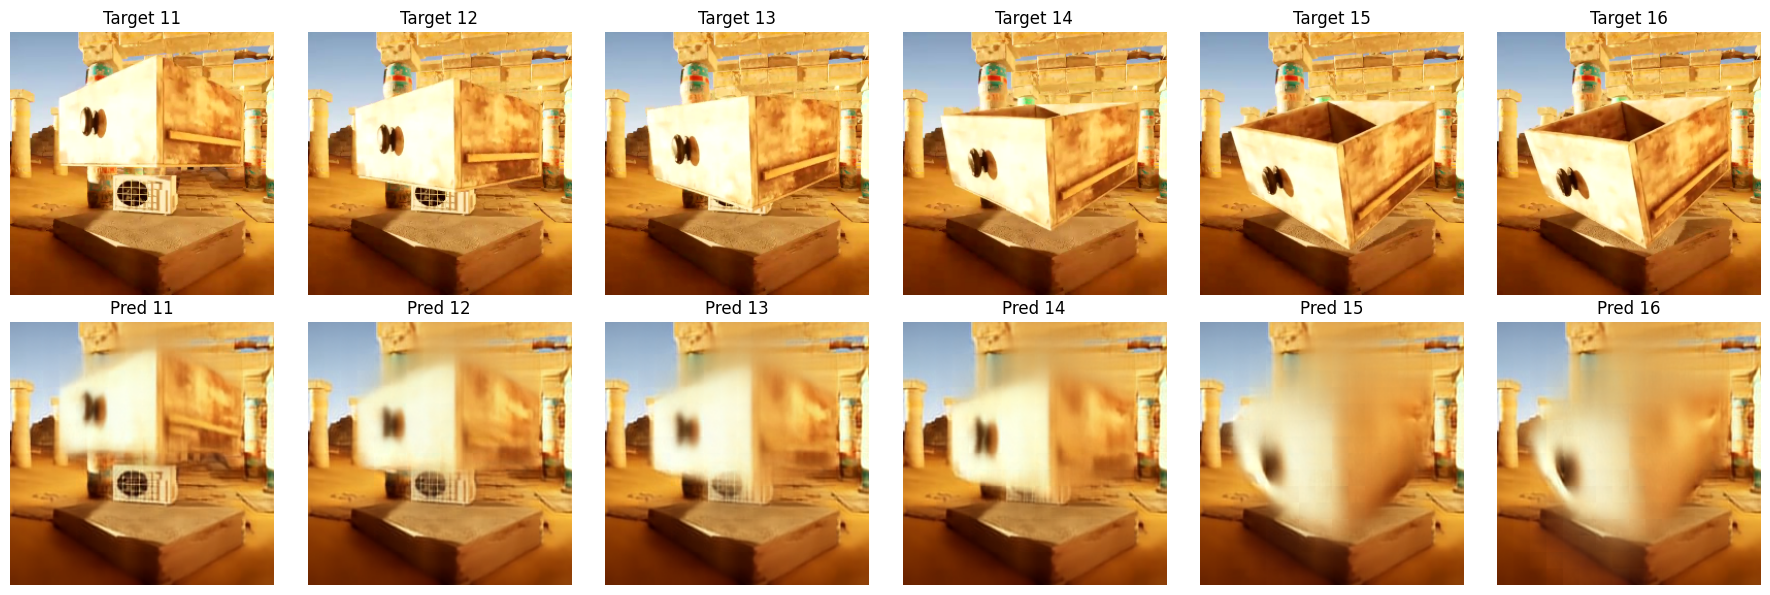

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

targets = target_frames[0]  # (6, 512, 512, 3)
preds = recon[0]            # (6, 512, 512, 3)

fig, axes = plt.subplots(2, 6, figsize=(18, 6))

for i in range(6):
    target = np.asarray(targets[i])

    # If target is already black, this will just display it
    if target.max() > 1:
        target = target.astype(np.uint8)
    else:
        target = (np.clip(target, 0, 1) * 255).astype(np.uint8)

    axes[0, i].imshow(target)
    axes[0, i].set_title(f"Target {target_deltas[i]}")
    axes[0, i].axis("off")

    image = np.asarray(preds[i]).astype(np.float32)

    print(f"Pred {i}: {image.shape}, {image.min():.4f}, {image.max():.4f}")

    # [0, 1] -> [0, 255]
    image = np.clip(image, 0.0, 1.0)
    image = (image * 255.0).astype(np.uint8)

    # recon is RGB, matplotlib expects RGB
    axes[1, i].imshow(image)
    axes[1, i].set_title(f"Pred {target_deltas[i]}")
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Target", fontsize=14)
axes[1, 0].set_ylabel("Pred", fontsize=14)

plt.tight_layout()
plt.show()

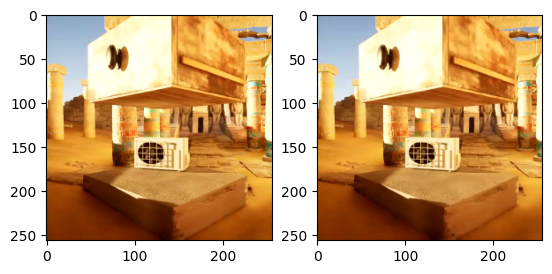

In [46]:
frame1, frame2 = source_frames[:, -2,...].squeeze(0), source_frames[:, -1,...].squeeze(0)
frame1 = (np.clip(frame1, 0, 1) * 255).astype(np.uint8)
frame2 = (np.clip(frame2, 0, 1) * 255).astype(np.uint8)

plt.subplot(1, 2, 1)
plt.imshow(frame1)
plt.subplot(1, 2, 2)
plt.imshow(frame2)

In [28]:
output['decoded_representation'].shape

(1, 6, 256, 512)

vjepa2.1

In [1]:

from models.make_model_vj2_1 import  vjepa2_1_vit_giant_384

ImportError: cannot import name 'vit_encoder' from partially initialized module 'models_vj2.vision_transformer' (most likely due to a circular import) (/home/rvm/src/models/models_vj2/vision_transformer.py)